In [2]:
import pandas as pd 

In [3]:
import numpy as np 

In [4]:
df = pd.read_csv("SCMS_Delivery_History_Dataset.csv")

In [5]:
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [6]:
df.shape

(10324, 33)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [9]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [10]:
df.replace(
    [
        "Date Not Captured",
        "N/A",
        "Weight Captured Separately",
        "Invoiced Separately",
        "Freight Included in Commodity Cost"
    ],
    np.nan,
    inplace=True
)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date     205
PO Sent to Vendor Date           328
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10119 non-null  object 
 11  PO Sent to Vendor Date        9996 non-null   object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [14]:
date_cols = [
    'PO Sent to Vendor Date',
    'Scheduled Delivery Date',
    'Delivered to Client Date',
    'Delivery Recorded Date'
]

In [15]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

C:\Users\HP\AppData\Local\Temp\ipykernel_19776\4293999390.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\HP\AppData\Local\Temp\ipykernel_19776\4293999390.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\HP\AppData\Local\Temp\ipykernel_19776\4293999390.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\HP\AppData\Local\Temp\ipykernel_19776\4293999390.py:2: UserWarning: Could not infer form

In [16]:
df['PQ First Sent to Client Date'] = pd.to_datetime(
    df['PQ First Sent to Client Date'],
    errors='coerce',
    dayfirst=True
)

C:\Users\HP\AppData\Local\Temp\ipykernel_19776\2381611289.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['PQ First Sent to Client Date'] = pd.to_datetime(


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            10324 non-null  int64         
 1   Project Code                  10324 non-null  object        
 2   PQ #                          10324 non-null  object        
 3   PO / SO #                     10324 non-null  object        
 4   ASN/DN #                      10324 non-null  object        
 5   Country                       10324 non-null  object        
 6   Managed By                    10324 non-null  object        
 7   Fulfill Via                   10324 non-null  object        
 8   Vendor INCO Term              10324 non-null  object        
 9   Shipment Mode                 9964 non-null   object        
 10  PQ First Sent to Client Date  7643 non-null   datetime64[ns]
 11  PO Sent to Vendor Date      

In [18]:
df[date_cols].head(20)

,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date
0,NaT,2006-06-02,2006-06-02,2006-06-02
1,NaT,2006-11-14,2006-11-14,2006-11-14
2,NaT,2006-08-27,2006-08-27,2006-08-27
3,NaT,2006-09-01,2006-09-01,2006-09-01
4,NaT,2006-08-11,2006-08-11,2006-08-11
5,NaT,2006-09-28,2006-09-28,2006-09-28
6,NaT,2007-01-08,2007-01-08,2007-01-08
7,NaT,2006-11-24,2006-11-24,2006-11-24
8,NaT,2006-12-07,2006-12-07,2006-12-07
9,2006-11-13,2007-01-30,2007-01-30,2007-01-30


In [19]:
numeric_cols = [
    'Line Item Quantity',
    'Line Item Value',
    'Pack Price',
    'Unit Price',
    'Weight (Kilograms)',
    'Freight Cost (USD)',
    'Line Item Insurance (USD)'
]

In [20]:
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [21]:
df[numeric_cols].head(20)

,Line Item Quantity,Line Item Value,Pack Price,Unit Price,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,19,551.00,29.00,0.97,13.0,780.34,NaN
1,1000,6200.00,6.20,0.03,358.0,4521.50,NaN
2,500,40000.00,80.00,0.80,171.0,1653.78,NaN
3,31920,127360.80,3.99,0.07,1855.0,16007.06,NaN
4,38000,121600.00,3.20,0.05,7590.0,45450.08,NaN
5,416,2225.60,5.35,0.02,504.0,5920.42,NaN
6,135,4374.00,32.40,0.36,328.0,NaN,NaN
7,16667,60834.55,3.65,0.06,1478.0,6212.41,NaN
8,273,532.35,1.95,0.03,NaN,NaN,NaN
9,2800,115080.00,41.10,0.34,643.0,NaN,NaN


In [22]:
df['Shipment Mode'] = df['Shipment Mode'].str.upper()
df['Country'] = df['Country'].str.title()

In [23]:
df['Country'].head(20)

0     Côte D'Ivoire
1           Vietnam
2     Côte D'Ivoire
3           Vietnam
4           Vietnam
5           Nigeria
6            Zambia
7          Tanzania
8           Nigeria
9            Zambia
10           Zambia
11           Zambia
12          Nigeria
13           Rwanda
14            Haiti
15         Zimbabwe
16          Nigeria
17           Rwanda
18         Tanzania
19          Nigeria
Name: Country, dtype: object

In [24]:
df['Shipment Mode'].head(20)

0     AIR
1     AIR
2     AIR
3     AIR
4     AIR
5     AIR
6     AIR
7     AIR
8     AIR
9     AIR
10    AIR
11    AIR
12    AIR
13    AIR
14    AIR
15    AIR
16    NaN
17    AIR
18    AIR
19    AIR
Name: Shipment Mode, dtype: object

In [25]:
df['Freight Cost Per KG'] = (
    df['Freight Cost (USD)']
    / df['Weight (Kilograms)']
)

In [26]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date    2681
PO Sent to Vendor Date          5732
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            10324 non-null  int64         
 1   Project Code                  10324 non-null  object        
 2   PQ #                          10324 non-null  object        
 3   PO / SO #                     10324 non-null  object        
 4   ASN/DN #                      10324 non-null  object        
 5   Country                       10324 non-null  object        
 6   Managed By                    10324 non-null  object        
 7   Fulfill Via                   10324 non-null  object        
 8   Vendor INCO Term              10324 non-null  object        
 9   Shipment Mode                 9964 non-null   object        
 10  PQ First Sent to Client Date  7643 non-null   datetime64[ns]
 11  PO Sent to Vendor Date      

In [28]:
df['Shipment Mode'].fillna(
    df['Shipment Mode'].mode()[0],
    inplace=True
)

C:\Users\HP\AppData\Local\Temp\ipykernel_19776\1209971474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Shipment Mode'].fillna(


In [29]:
df['Line Item Insurance (USD)'].fillna(0, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_19776\3490072090.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Line Item Insurance (USD)'].fillna(0, inplace=True)


In [30]:
df['Weight (Kilograms)'].fillna(
    df['Weight (Kilograms)'].median(),
    inplace=True
)

C:\Users\HP\AppData\Local\Temp\ipykernel_19776\2308959978.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weight (Kilograms)'].fillna(


In [31]:
df['Freight Cost (USD)'].fillna(
    df['Freight Cost (USD)'].median(),
    inplace=True
)

C:\Users\HP\AppData\Local\Temp\ipykernel_19776\1377726880.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Freight Cost (USD)'].fillna(


In [32]:
df['Freight Cost Per KG'] = (
    df['Freight Cost (USD)']
    / df['Weight (Kilograms)']
)

In [33]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                      0
PQ First Sent to Client Date    2681
PO Sent to Vendor Date          5732
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [34]:
df['Delay Days'] = (
    df['Delivered to Client Date']
    - df['Scheduled Delivery Date']
).dt.days

In [35]:
df['Delivery Status'] = df['Delay Days'].apply(
    lambda x:
    'Late' if x > 0
    else ('Early' if x < 0 else 'On Time')
)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            10324 non-null  int64         
 1   Project Code                  10324 non-null  object        
 2   PQ #                          10324 non-null  object        
 3   PO / SO #                     10324 non-null  object        
 4   ASN/DN #                      10324 non-null  object        
 5   Country                       10324 non-null  object        
 6   Managed By                    10324 non-null  object        
 7   Fulfill Via                   10324 non-null  object        
 8   Vendor INCO Term              10324 non-null  object        
 9   Shipment Mode                 10324 non-null  object        
 10  PQ First Sent to Client Date  7643 non-null   datetime64[ns]
 11  PO Sent to Vendor Date      

In [37]:
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                      0
PQ First Sent to Client Date    2681
PO Sent to Vendor Date          5732
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [38]:
df.describe()

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,ID,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD),Freight Cost Per KG,Delay Days
count,10324.000000,7643,4592,10324,10324,10324,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000
mean,51098.968229,2012-06-07 08:05:31.597540096,2012-01-25 07:21:13.170731776,2011-10-04 15:30:28.593568512,2011-09-28 14:56:34.963192576,2011-10-01 12:33:28.523827968,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,2514.363038,9011.627852,233.442523,inf,-6.023537
min,1.000000,2009-01-07 00:00:00,2006-04-19 00:00:00,2006-05-02 00:00:00,2006-05-02 00:00:00,2006-05-02 00:00:00,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.750000,0.000000,5.392379e-04,-372.000000
25%,12795.750000,2010-11-26 00:00:00,2010-02-04 00:00:00,2009-09-08 00:00:00,2009-09-01 00:00:00,2009-09-01 00:00:00,30.000000,408.000000,4.314593e+03,4.120000,0.080000,617.000000,4323.807500,5.242500,5.393017e+00,-3.000000
50%,57540.500000,2012-08-23 00:00:00,2012-06-07 00:00:00,2011-12-05 00:00:00,2011-11-25 00:00:00,2011-11-25 00:00:00,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,1047.000000,5869.655000,42.815000,5.606165e+00,0.000000
75%,83648.250000,2013-11-07 00:00:00,2014-04-30 00:00:00,2013-12-23 00:00:00,2013-12-23 00:00:00,2014-01-13 00:00:00,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,1596.500000,7707.640000,241.750000,9.557145e+00,0.000000
max,86823.000000,2015-12-01 00:00:00,2015-08-24 00:00:00,2015-12-31 00:00:00,2015-09-14 00:00:00,2015-09-14 00:00:00,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,857354.000000,289653.200000,7708.440000,inf,192.000000
std,31944.332496,NaN,NaN,NaN,NaN,NaN,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,10689.424697,12517.228517,494.765813,NaN,27.233640


In [39]:
df.to_csv("Cleaned_supply_chain_data_new.csv", index=False)

EDA

In [40]:
df['Country'].value_counts().head(10)

Country
South Africa     1406
Nigeria          1194
Côte D'Ivoire    1083
Uganda            779
Vietnam           688
Zambia            683
Haiti             655
Mozambique        631
Zimbabwe          538
Tanzania          519
Name: count, dtype: int64

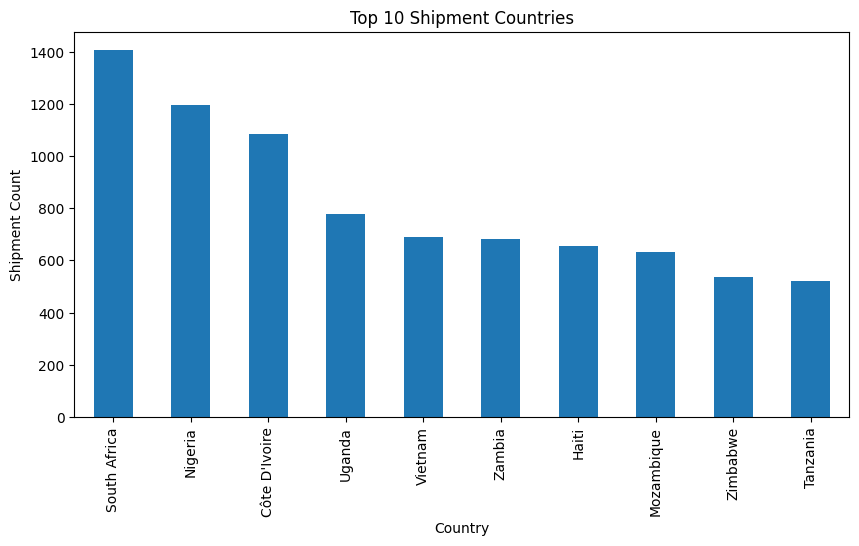

In [41]:
import matplotlib.pyplot as plt

df['Country'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Shipment Countries')
plt.ylabel('Shipment Count')
plt.show()

In [42]:
df['Shipment Mode'].value_counts()

Shipment Mode
AIR            6473
TRUCK          2830
AIR CHARTER     650
OCEAN           371
Name: count, dtype: int64

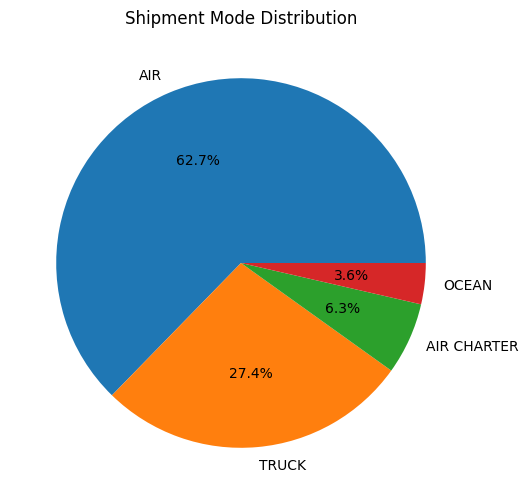

In [43]:
df['Shipment Mode'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Shipment Mode Distribution')
plt.ylabel('')
plt.show()

In [44]:
df['Delivery Status'].value_counts()

Delivery Status
On Time    6324
Early      2814
Late       1186
Name: count, dtype: int64

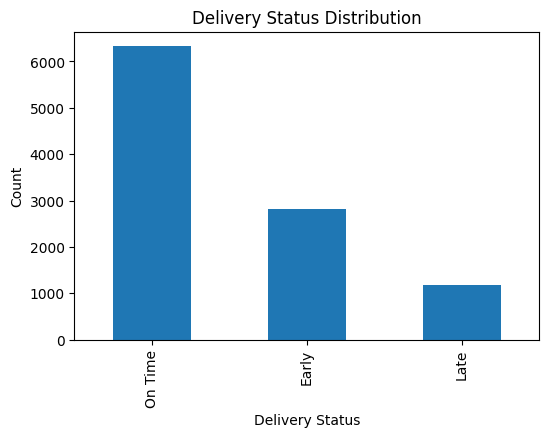

In [45]:
df['Delivery Status'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Delivery Status Distribution')
plt.ylabel('Count')
plt.show()

In [46]:
df['Delay Days'].mean()

np.float64(-6.023537388609066)

In [47]:
df.groupby('Country')['Delay Days'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

Country
Congo, Drc      11.240240
Togo             5.333333
Benin            2.384615
Senegal          1.000000
Kenya            0.891892
Burkina Faso     0.000000
Liberia          0.000000
Guinea           0.000000
Angola           0.000000
Lesotho          0.000000
Name: Delay Days, dtype: float64

In [48]:
df['Vendor'].value_counts().head(20)

Vendor
SCMS from RDC                                                        5404
Orgenics, Ltd                                                         754
S. BUYS WHOLESALER                                                    715
Aurobindo Pharma Limited                                              668
Trinity Biotech, Plc                                                  356
ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV)                       347
PHARMACY DIRECT                                                       326
MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORATORIES)                 317
HETERO LABS LIMITED                                                   277
CIPLA LIMITED                                                         175
CHEMBIO DIAGNOSTIC SYSTEMS, INC.                                      109
Standard Diagnostics, Inc.                                             98
STRIDES ARCOLAB LIMITED                                                93
SHANGHAI KEHUA BIOENGINEERING C

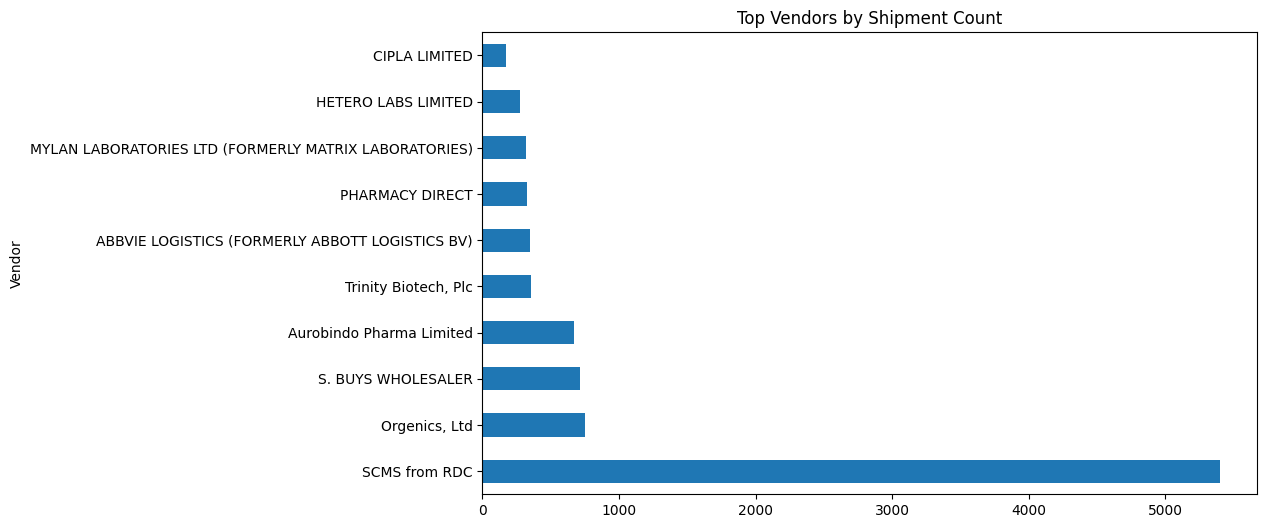

In [49]:
df['Vendor'].value_counts().head(10).plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top Vendors by Shipment Count')
plt.show()

In [50]:
df.groupby('Vendor')['Delay Days'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

Vendor
CIPLA LIMITED                                    4.777143
Aurobindo Pharma Limited                         4.411677
Abbott GmbH & Co. KG                             2.285714
BIO-RAD LABORATORIES (FRANCE)                    2.107143
EMCURE PHARMACEUTICALS LTD                       1.390244
SHANGHAI KEHUA BIOENGINEERING CO.,LTD.  (KHB)    1.057143
STRIDES ARCOLAB LIMITED                          0.978495
ASPEN PHARMACARE                                 0.878049
Orgenics, Ltd                                    0.838196
Orasure Technologies Inc.                        0.500000
Name: Delay Days, dtype: float64

In [51]:
df['Freight Cost (USD)'].describe()

count     10324.000000
mean       9011.627852
std       12517.228517
min           0.750000
25%        4323.807500
50%        5869.655000
75%        7707.640000
max      289653.200000
Name: Freight Cost (USD), dtype: float64

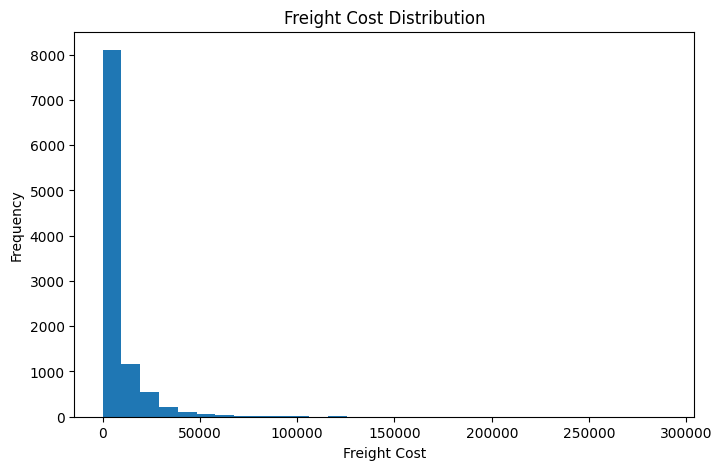

In [52]:
df['Freight Cost (USD)'].plot(
    kind='hist',
    bins=30,
    figsize=(8,5)
)

plt.title('Freight Cost Distribution')
plt.xlabel('Freight Cost')
plt.show()

In [53]:
df.groupby('Shipment Mode')['Freight Cost (USD)'] \
    .mean() \
    .sort_values(ascending=False)

Shipment Mode
AIR CHARTER    15773.308477
OCEAN          11086.598612
AIR             8811.597898
TRUCK           7644.096873
Name: Freight Cost (USD), dtype: float64

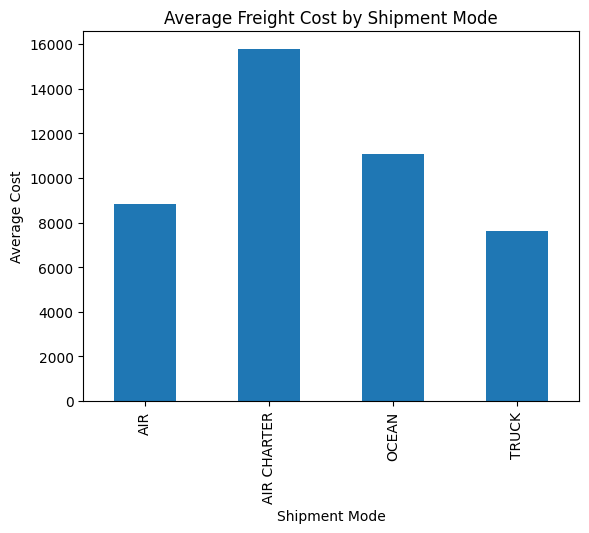

In [54]:
df.groupby('Shipment Mode')['Freight Cost (USD)'] \
    .mean() \
    .plot(kind='bar')

plt.title('Average Freight Cost by Shipment Mode')
plt.ylabel('Average Cost')
plt.show()

In [55]:
df[['Weight (Kilograms)',
    'Freight Cost (USD)']].corr()

,Weight (Kilograms),Freight Cost (USD)
Weight (Kilograms),1.000000,0.245879
Freight Cost (USD),0.245879,1.000000


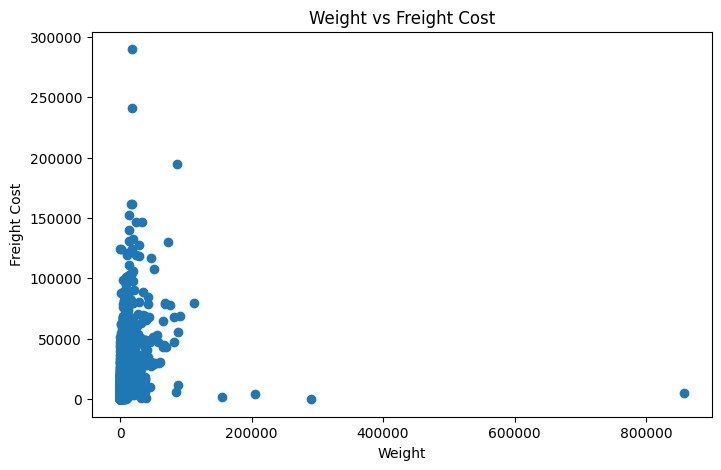

In [56]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['Weight (Kilograms)'],
    df['Freight Cost (USD)']
)
plt.xlabel('Weight')
plt.ylabel('Freight Cost')
plt.title('Weight vs Freight Cost')
plt.show()

In [57]:
df['Product Group'].value_counts()

Product Group
ARV     8550
HRDT    1728
ANTM      22
ACT       16
MRDT       8
Name: count, dtype: int64

In [58]:
pd.options.display.float_format = '{:,.2f}'.format

In [59]:
df.groupby('Molecule/Test Type')['Line Item Value'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)

Molecule/Test Type
Lamivudine/Nevirapine/Zidovudine                        300,755,250.15
Efavirenz/Lamivudine/Tenofovir Disoproxil Fumarate      230,639,842.14
Efavirenz                                               145,187,675.30
HIV 1/2, Determine Complete HIV Kit                     137,022,306.80
Lamivudine/Zidovudine                                   130,253,539.29
Efavirenz/Emtricitabine/Tenofovir Disoproxil Fumarate   106,190,100.38
Lopinavir/Ritonavir                                      87,643,675.53
Emtricitabine/Tenofovir Disoproxil Fumarate              70,831,172.16
Lamivudine/Tenofovir Disoproxil Fumarate                 65,768,346.98
Nevirapine                                               58,366,415.64
Name: Line Item Value, dtype: float64